# Module 2 Activity
### 625.662.81
#### Jeremy Mastrodomenico

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


---
## **Part 1**: Develop Questions
#### **Question 1:** Are there performance differences between students with standard lunch and free/reduced lunch?
#### **Question 2:** Are there performance differences between students who took a test preparation course and those who did not?
#### **Question 3:** Are there performance differences between students with higher degrees of parental level education?

## **Part 2**: Create Visualizations
### **Question 1**

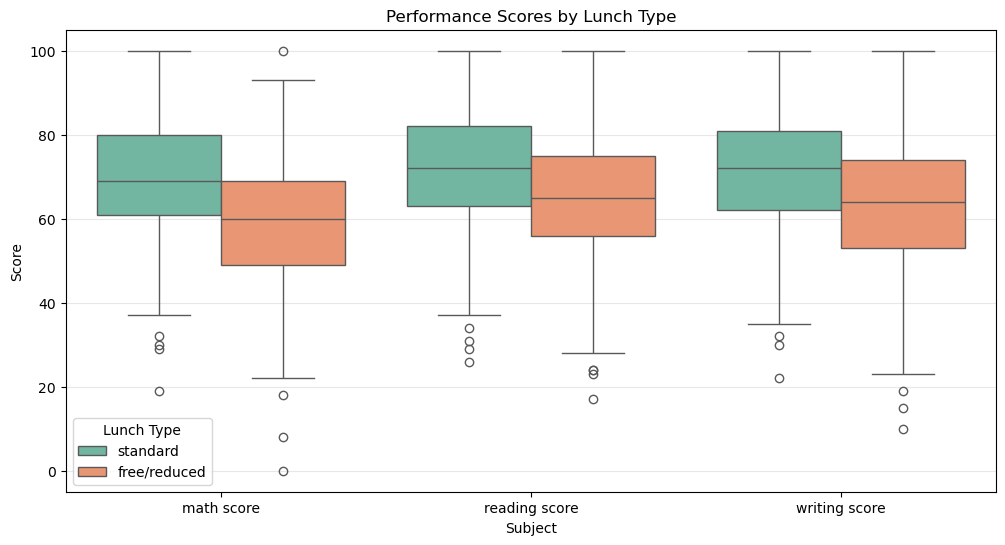

In [29]:
df_melt = pd.melt(df, 
                  id_vars=['lunch'], 
                  value_vars=['math score', 'reading score', 'writing score'],
                  var_name='Subject', 
                  value_name='Score')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='Subject', y='Score', hue='lunch', palette='Set2')
plt.title('Performance Scores by Lunch Type')
plt.xlabel('Subject')
plt.ylabel('Score')
plt.legend(title='Lunch Type')
plt.grid(axis='y', alpha=0.3)
plt.show()

*I do not believe a transformation would provide meaningful insights beyond those already visible.*

### **Question 2**

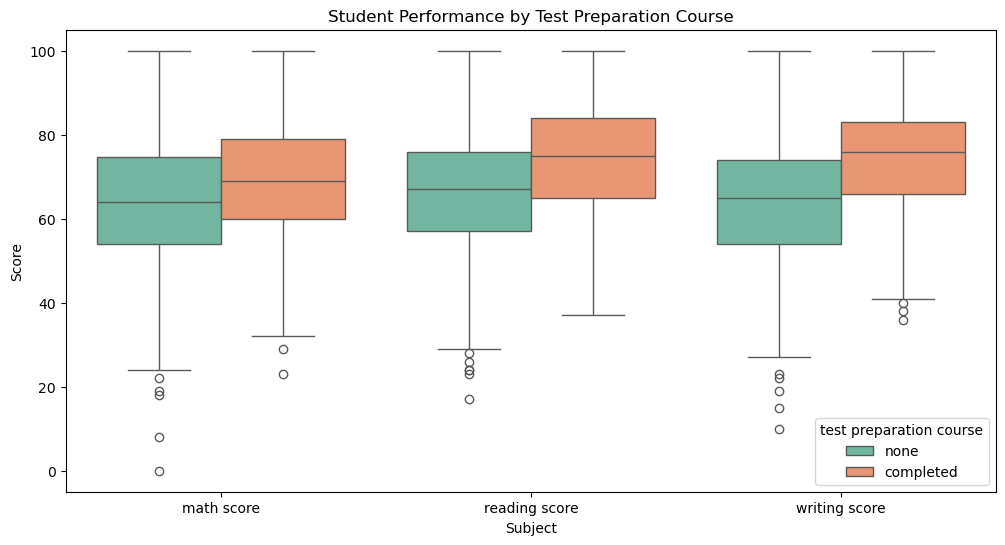

In [30]:
plt.figure(figsize=(12, 6))
melted = df.melt(
    id_vars='test preparation course',
    value_vars=['math score', 'reading score', 'writing score']
)

sns.boxplot(data=melted, x='variable', y='value', 
            hue='test preparation course', palette='Set2')

plt.title('Student Performance by Test Preparation Course')
plt.xlabel('Subject')
plt.ylabel('Score')
plt.show()

*I do not believe a transformation would provide meaningful insights beyond those already visible.*

### **Question 3**

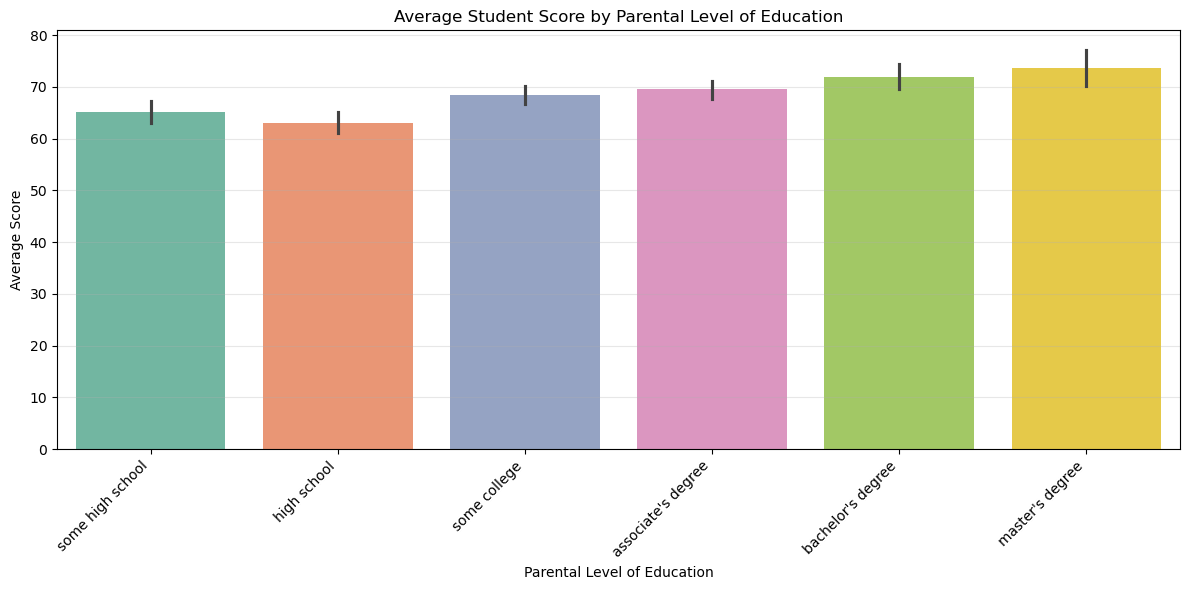

In [31]:
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Define education order
education_order = [
    'some high school',
    'high school',
    'some college',
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

# Set ordered categories
df['parental level of education'] = pd.Categorical(
    df['parental level of education'], 
    categories=education_order, 
    ordered=True
)


plt.figure(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='parental level of education', 
    y='average score',
    hue='parental level of education',     
    errorbar=('ci', 95),
    palette='Set2',
    legend=False                       
)

plt.title('Average Student Score by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

*The data visualization for question 3 was difficult so I applied two transformations. First, I averaged the subject matter scores then I ordered the education levels for the best results*

## **Part 3**: Provide Context
### **Question 1**
I find the question posed in Part 1 to be meaningful as I empirically find I do my best work on a full, hearty meal as opposed to a smaller meal. To represent this I felt a box-plot was appropriate to emphasize the subject score ranges with respect to lunch type. Across all subjects, standard lunch yielded more better scores with more compact ranges. Conversely, free/reduced lunch yielded lower scores with larger overall ranges. It is important to note that most outliers occurred at lower scores (between 0 and 40) rather than higher scores, as they were generally encapsulated within the box-plot range.

### **Question 2**
 I find the question post in Part 2 relateable for when I took the SAT. Historically I never needed to study nor take test prep and my mom forced me to do so to improve my SAT score. Needless to say she was right and it worked. Aside from my personal experience (again), the students did have meaningful improvements across all subjects having completed the course compared with those who did not. Additionally, the students who did not complete the course had the most significant outliers whereas there were very few in the group who did complete the course.
 
### **Question 3**
It is important to see whether there is a meaningful improvement to scores based on relative education level because if there weren't either the dataset is too small or we need to restructure society. Jokes aside, there is a clear upward trend with the exclusion of high school and "some high school" having a downward trend. Interesting observation. Given that I applied an average as my transformation, it is not easy to interpret outliers and another visualization technique would need to be employed for this information.

## **Part 4**: Reflect & Share

For questions 1 & 2 I felt that the box-plot justly represented the data and provided insights into performance without additional transformations to be applied. We can see the overall trend broken up by each respective group, view the outliers and their significance, and interpret the data for insights. Question 3 was a bit of a challenge. When I initially applied the histogram with the subjects it still missed the outliers but 15 histograms doesn't tell a very insightful story about the data, especially when it is uncategorized. That was why I decided to average and categorize the data. Both decisions make the data much more interpretable to human eyes. If I were to continue with this activity, maybe I would find a way to better represent the data from question 3 which may or may not also include the outliers.  